In [2]:
import numpy as np
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import pylab as pyl
import pywt
import pandas as pd


import os
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

pytorch_fid_src = project_root / "lib" / "pytorch-fid-master" / "src"
if str(pytorch_fid_src) not in sys.path:
    sys.path.insert(0, str(pytorch_fid_src))

from lib.cea_lib.signal1D import*
from lib.cea_lib.general import*
from lib.cea_lib.data_loader import*
from lib.cea_lib.output import*

In [3]:
import matplotlib.pyplot as plt

REPORT_PLOT_STYLE = {
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13,
    "figure.titlesize": 18,
}
plt.rcParams.update(REPORT_PLOT_STYLE)


# Ondelettes 1D

Cas classique du signale s:

- rellement continue tel que s(t)
- discretisé sous forme s[t]

Ici on peut appliquer la [DWT](https://pywavelets.readthedocs.io/en/latest/ref/dwt-discrete-wavelet-transform.html) (Discret Wavelet Transform).

Ici je voudrais aussi regarder les difference entre wavelet orthogonales et biorthogonales en plus de leur caracteristique mathématiques,
| Propriété | Orthogonale | Biorthogonale |
| ----------- | ----------- | ----------- |
| énergie conservée | oui | non |
| symétrie | non | oui |
| filtres identiques| oui | non |

Pour ce faire j'aimerais comparer différente [familles des wavelets](https://pywavelets.readthedocs.io/en/latest/ref/wavelets.html) et faire des visualisation comme dans la documentation sur la [CWT](https://pywavelets.readthedocs.io/en/latest/ref/cwt.html)
(Continuous Wavelet Transofrm)

Liste apriori des wavelet interessantes pour ce probleme,
| Orthogonale | Biorthogonale |
| ----------- | ----------- |
| dataN | biorX.Y |
| symN | rbioX.Y |
| haar (data1) | |
| dmey | |


In [4]:
wavelets_list = [
    "haar",
    "db8",
    "sym6",
    # "sym8",
    "coif3",
    # "bior4.4"
]

# wavelets_list = pywt.wavelist('bior')
print(wavelets_list)

['haar', 'db8', 'sym6', 'coif3']


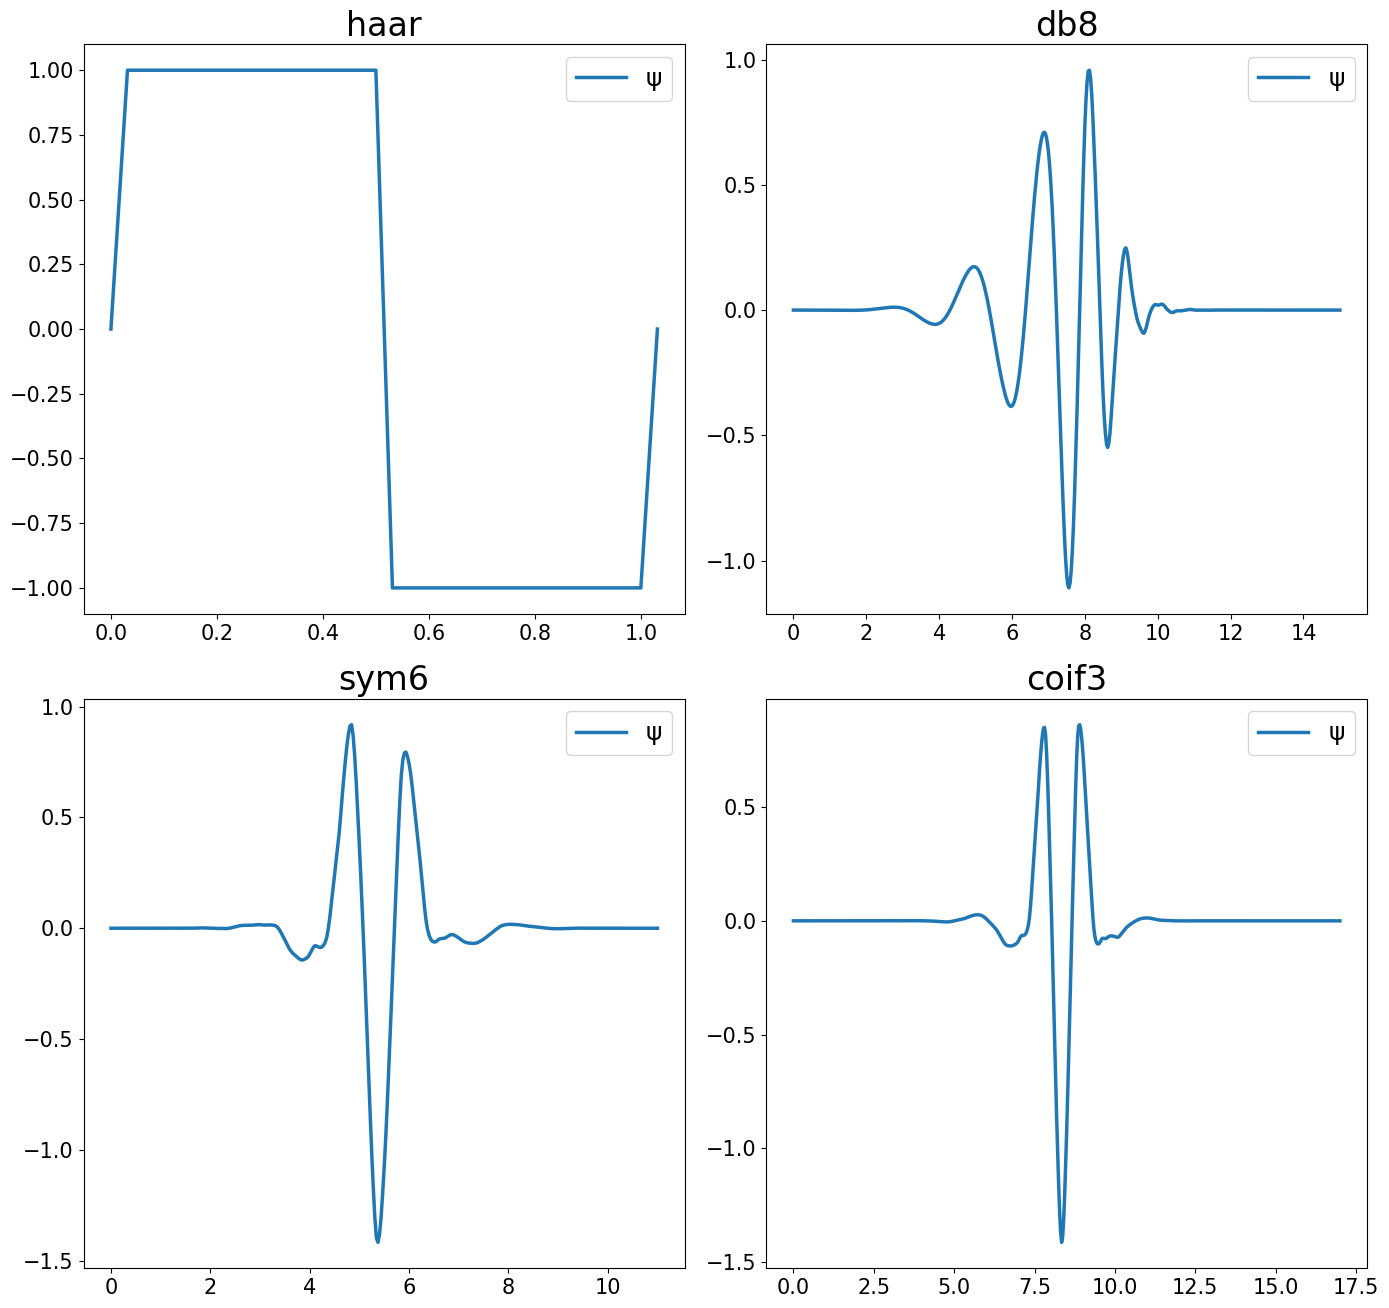

In [5]:
cols = 2
rows = (len(wavelets_list) + cols - 1) // cols

title_fontsize = 24
suptitle_fontsize = 30
legend_fontsize = 18
tick_fontsize = 15
line_width = 2.5

fig, axs = plt.subplots(rows, cols, figsize=(14, 7 * rows),
                        sharex=False, sharey=False)
# fig.suptitle("Fonctions d'ondelettes 1D", fontsize=suptitle_fontsize)

axs = np.array(axs).flatten()

for ax, wname in zip(axs, wavelets_list):

    wavelet = pywt.Wavelet(wname)

    # wavefun renvoie scaling function + wavelet function
    result = wavelet.wavefun(level=5)

    if len(result) == 2:
        psi, x = result
        ax.plot(x, psi, linewidth=line_width, label="ψ")

    elif len(result) == 3:
        phi, psi, x = result
        ax.plot(x, psi, linewidth=line_width, label="ψ")
        # ax.plot(x, phi, label="φ")

    elif len(result) == 5:
        phi_d, psi_d, phi_r, psi_r, x = result
        ax.plot(x, psi_d, linewidth=line_width, label="ψ_d")
        ax.plot(x, psi_r, linewidth=line_width, label="ψ_r")
        # ax.plot(x, phi_d, label="φ_d")
        # ax.plot(x, phi_r, label="φ_r")

    else:
        raise ValueError(f"Format unknown for {wavelet.name}")

    ax.set_title(wname, fontsize=title_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    ax.legend(fontsize=legend_fontsize)

# cacher axes inutiles
for ax in axs[len(wavelets_list):]:
    ax.axis("off")



plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../doc/BDRPReportTemplate/figures/ch2/wave.png", dpi=300, bbox_inches="tight")
plt.show()

## Application sur un signale

In [6]:
data, labels = load_RTCEA("../data/RTCEA_bimode.hdf5")
atwood = create_atwood_dic(labels)
idxs = atwood[0.3]
sim = data[idxs,:,:] 

In [7]:
x = sim.shape[2]//2
img= sim[sim.shape[0]-1,:,:] # la derniere image du fichier
sig = img[:,x]

atwood = labels[sim.shape[0]-1,0]
time   = labels[sim.shape[0]-1,1]

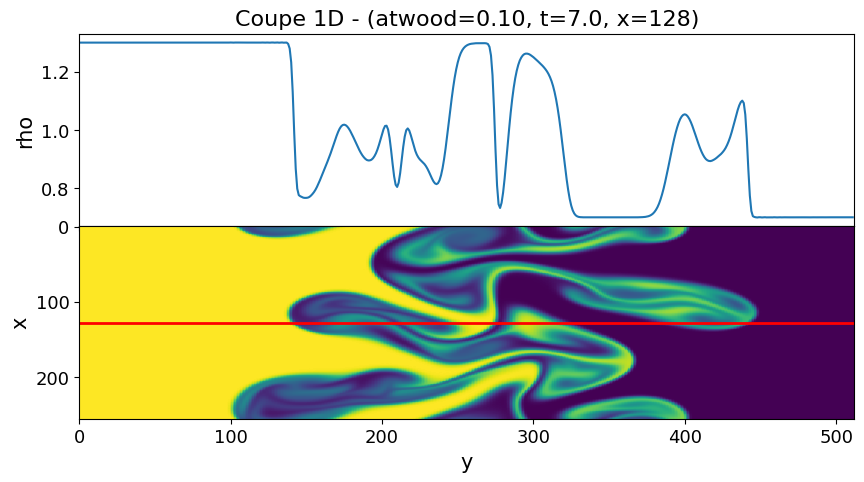

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

ax[0].plot(sig)
ax[0].set_xlim(0, sim.shape[1])
ax[0].set_title(f'Coupe 1D - (atwood={atwood:.2f}, t={time:.1f}, x={x})')
ax[0].set_ylabel("rho")

ax[1].imshow(img.T, interpolation='nearest', aspect='auto')
ax[1].axhline(y=sim.shape[2]//2, color='red', linewidth=2)
ax[1].set_xlabel("y")
ax[1].set_ylabel("x")

fig.subplots_adjust(hspace=0)
# plt.savefig("../img/signal/1D_signal.png", dpi=300)
plt.show()

In [9]:
M = 6
wavelet = "haar"
wr = wavelet_non_lineaire(sig, M, wavelet)

Lors de la reconstruction **wf = wf + wi** correspondant a

$$f_M(t) = \sum_{ i \in I_M }c_i\cdot \psi_i(t).$$

**wi** correspond a $c_i\cdot \psi_i(t)$ pas besoins de le multiplier par $c_i

> Numeriquement il faut garder les coefficient et leur index ainsi que la taille de l'espace de base pour pouvoir faire la transformé inverse (liste complète de coeffs avec des zéros partout sauf là où tu veux)


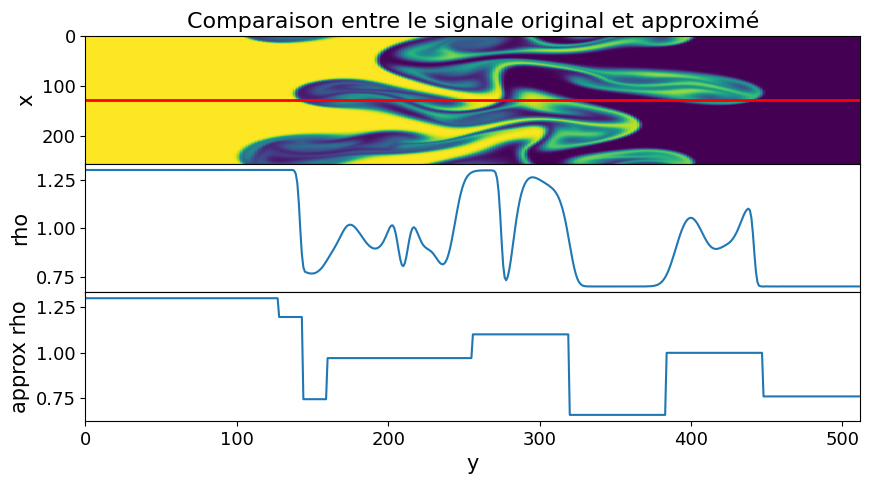

In [10]:
fig, ax = plt.subplots(3, 1, figsize=(10, 5), sharex=True)

ax[0].set_title(f'Comparaison entre le signale original et approximé')
ax[0].imshow(img.T, interpolation='nearest', aspect='auto')
ax[0].axhline(y=sim.shape[2]//2, color='red', linewidth=2)
ax[0].set_xlabel("y")
ax[0].set_ylabel("x")

ax[1].plot(sig)
ax[1].set_xlim(0, sim.shape[1])
ax[1].set_ylabel("rho")

ax[2].plot(wr)
ax[2].set_xlabel("y")
ax[2].set_ylabel("approx rho")



fig.subplots_adjust(hspace=0)
# plt.savefig("img/wavelet/1DExemple_Decomposition.png", dpi=300)
plt.show()

In [11]:
w = pywt.wavedec(sig, wavelet)
wf = np.zeros_like(sig)

arr, slices = pywt.coeffs_to_array(w)
n_levels = len(slices) - 1

flat = np.abs(arr).flatten()
idx = np.argsort(flat)
arr_f = np.zeros_like(arr)

arr_f.flat[idx[-M:]] = arr.flat[idx[-M:]]
idx = arr_f.nonzero()[0]
sorted_idx = idx[np.argsort(np.abs(arr_f[idx]))[::-1]]


cmap = plt.cm.plasma

level_colors = {
    level: cmap(level / max(1, n_levels))
    for level in range(n_levels + 1)
}

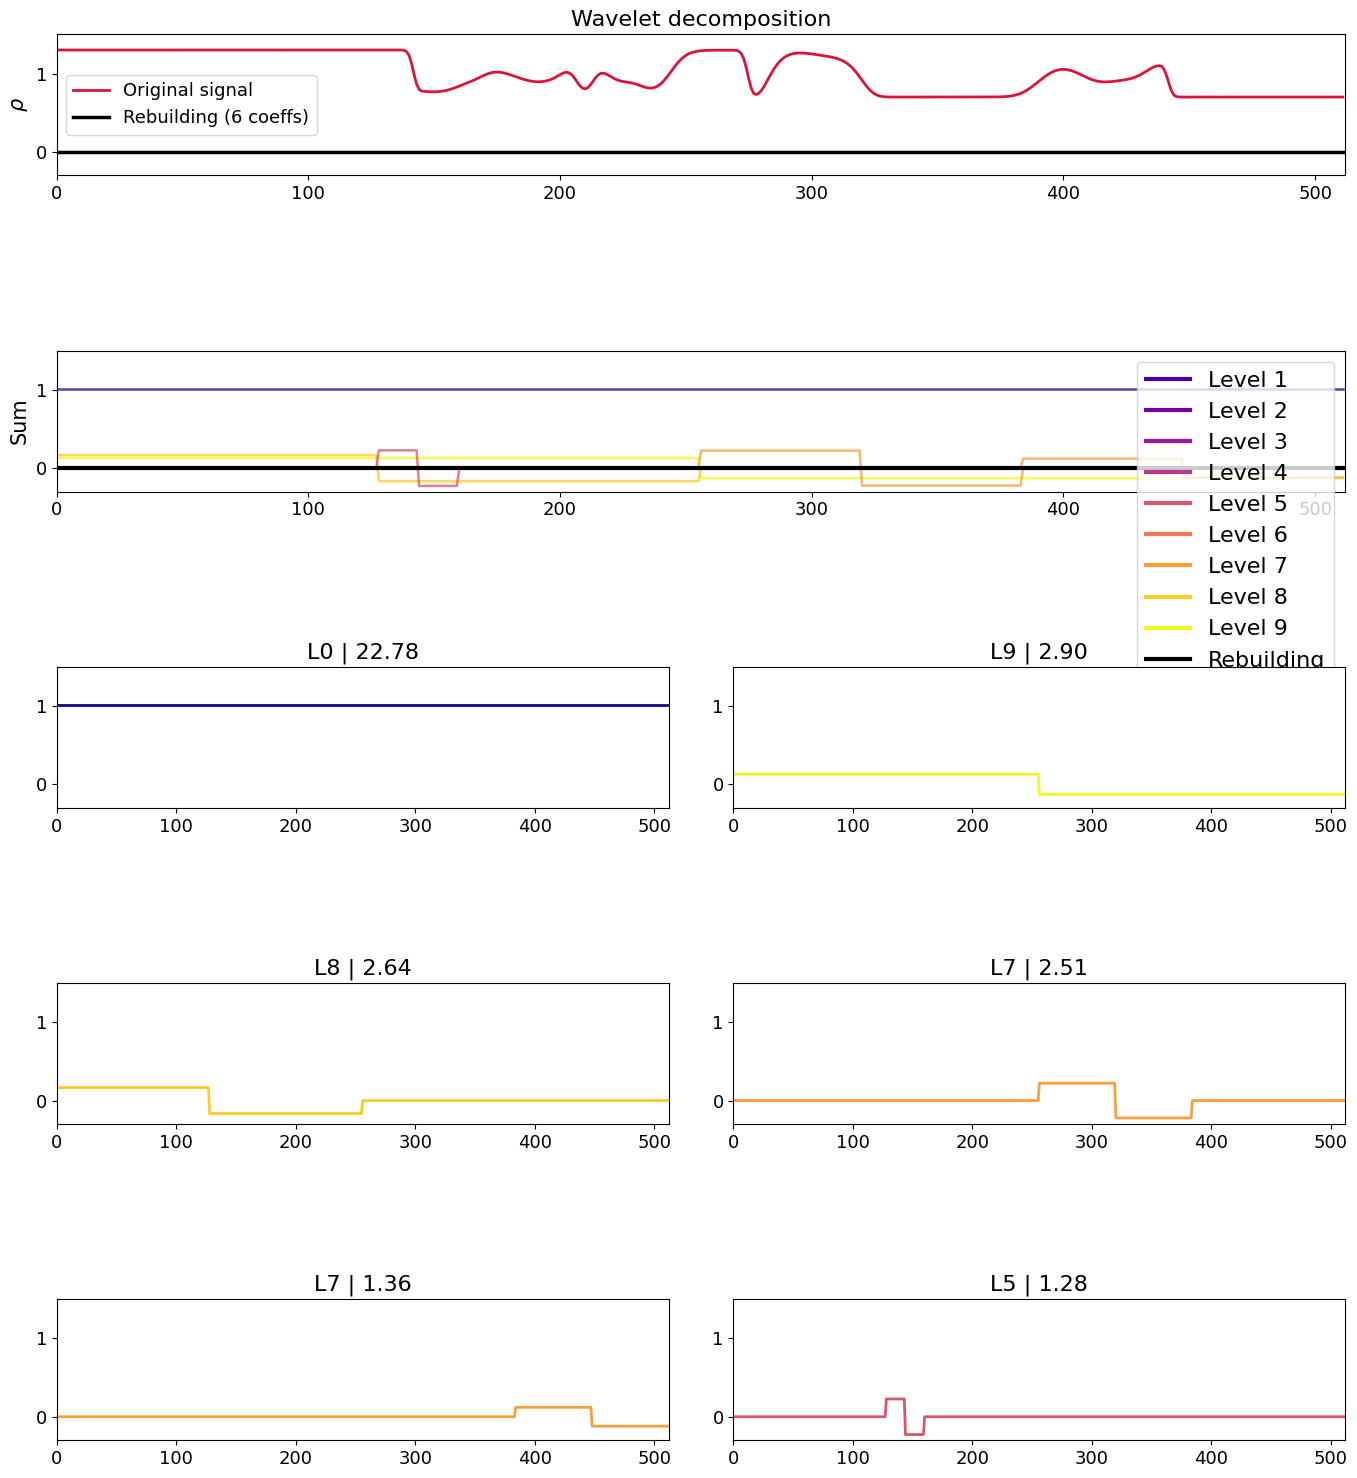

In [12]:
# --------------------------------------------------------
# Association coefficient -> niveau wavelet
# --------------------------------------------------------

level_map = np.zeros(arr.shape, dtype=int)

start = 0

# Approximation
n = len(w[0])
level_map[start:start+n] = 0
start += n

# Détails
for level, coeff in zip(
        range(len(w)-1, 0, -1),
        w[1:]):

    n = len(coeff)

    level_map[start:start+n] = level

    start += n

n_levels = len(w) - 1

cmap = plt.cm.plasma

level_colors = {
    level: cmap(level / max(1, n_levels))
    for level in range(n_levels + 1)
}

# --------------------------------------------------------
# Plot
# --------------------------------------------------------
y_supp = 1.5
y_inf = -0.3

import math

n_detail = len(sorted_idx)
ncols = 2
nrows_detail = math.ceil(n_detail / ncols)

fig = plt.figure(figsize=(14, 3 * (nrows_detail + 2)))
gs = fig.add_gridspec(nrows_detail + 2, ncols)

# --------------------------------------------------------
# Signal original + reconstruction
# --------------------------------------------------------
ax0 = fig.add_subplot(gs[0, :])

ax0.plot(sig, color="crimson", lw=2, label="Original signal")
ax0.plot(
    wf,
    color="black",
    lw=2.5,
    label=f"Rebuilding ({M} coeffs)"
)

ax0.legend()
ax0.set_xlim(0, len(sig))
ax0.set_ylim(y_inf, y_supp)
ax0.set_title("Wavelet decomposition", fontsize=16)
ax0.set_ylabel(r"$\rho$")

# --------------------------------------------------------
# Superposition des composantes
# --------------------------------------------------------
ax1 = fig.add_subplot(gs[1, :], sharex=ax0)

# Légende des niveaux
for lev in range(1, n_levels + 1):
    ax1.plot(
        [],
        [],
        color=level_colors[lev],
        lw=3,
        label=f"Level {lev}"
    )

# --------------------------------------------------------
# Coefficients individuels
# --------------------------------------------------------
for k, i in enumerate(sorted_idx):

    arr_fi = np.zeros_like(arr)
    arr_fi.flat[i] = arr.flat[i]

    coeffs_f = pywt.array_to_coeffs(
        arr_fi,
        slices,
        output_format="wavedec"
    )

    wi = pywt.waverec(coeffs_f, wavelet)
    wi = wi[:len(sig)]

    level = level_map[i]
    color = level_colors[level]

    # subplot individuel
    row = 2 + k // ncols
    col = k % ncols

    ax = fig.add_subplot(gs[row, col], sharex=ax0)

    ax.plot(wi, color=color, lw=2)

    ax.set_ylim(y_inf, y_supp)

    ax.set_title(
        f"L{level} | {arr.flat[i]:.2f}",
        fontsize=16
    )

    # plot global
    ax1.plot(
        wi,
        color=color,
        alpha=0.75,
        lw=1.8
    )

ax1.plot(
    wf,
    color="black",
    lw=3,
    label="Rebuilding"
)

ax1.set_ylabel("Sum")
ax1.set_ylim(y_inf, y_supp)
ax1.legend(loc="upper right", fontsize=16)

plt.tight_layout()
plt.savefig("../doc/BDRPReportTemplate/figures/ch2/1Dwavelets_Decomposition.png", dpi=300, bbox_inches="tight")
plt.show()

---
# Ondelette 2D

## Visualisation des coefficients 2D

L'objectif ici est de garder uniquement les coefficients d'ondelettes les plus grands en valeur absolue. Le masque affiche donc les positions des coefficients conservés dans le plan des coefficients PyWavelets.

In [13]:
from PIL import Image
import warnings


def prepare_image(path, n):
    """Charge une image RGB, la rend carrée puis la normalise entre 0 et 1."""
    img = Image.open(path).convert("RGB")
    n0 = min(img.size)
    img = img.crop((0, 0, n0, n0))
    img = img.resize((n, n))

    img = np.asarray(img, dtype=float)
    img = img / np.max(img)
    return np.clip(img, 0, 1)


n_img = 512
ratio_coeffs = 0.1
wavelet_2d = "bior3.5"
level_2d = int(np.floor(np.log2(n_img)) - 3)
# level_2d = 1

img = prepare_image("imageRT.png", n_img)

print("taille image :", img.shape)
print("niveau de decomposition :", level_2d)


taille image : (512, 512, 3)
niveau de decomposition : 6


In [14]:
def keep_large_wavelet_coeffs(channel, ratio, wavelet="bior3.5", level=3):
    """Reconstruit un canal en ne gardant que les plus grands coefficients."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        coeffs = pywt.wavedec2(channel, wavelet=wavelet, level=level)

    coeffs_array, coeffs_slices = pywt.coeffs_to_array(coeffs)
    n_keep = max(1, min(coeffs_array.size, int(ratio * coeffs_array.size)))

    amplitudes = np.abs(coeffs_array).ravel()
    threshold = np.partition(amplitudes, -n_keep)[-n_keep]
    mask = np.abs(coeffs_array) >= threshold

    coeffs_array_filtered = coeffs_array * mask
    coeffs_filtered = pywt.array_to_coeffs(
        coeffs_array_filtered,
        coeffs_slices,
        output_format="wavedec2",
    )
    channel_rec = pywt.waverec2(coeffs_filtered, wavelet=wavelet)

    return channel_rec, mask, coeffs_slices


def compress_rgb_wavelets(img, ratio, wavelet="bior3.5", level=1):
    img_rec = np.zeros_like(img)
    masks = []
    coeffs_slices = None

    for k in range(img.shape[2]):
        channel_rec, mask, coeffs_slices = keep_large_wavelet_coeffs(
            img[:, :, k],
            ratio,
            wavelet=wavelet,
            level=level,
        )
        img_rec[:, :, k] = channel_rec[:img.shape[0], :img.shape[1]]
        masks.append(mask)

    # Un coefficient est affiché si au moins un canal RGB le conserve.
    mask_rgb = np.any(masks, axis=0)
    return np.clip(img_rec, 0, 1), mask_rgb, coeffs_slices


img_wavelet, mask_wavelet, coeffs_slices = compress_rgb_wavelets(
    img,
    ratio_coeffs,
    wavelet=wavelet_2d,
    level=level_2d,
)


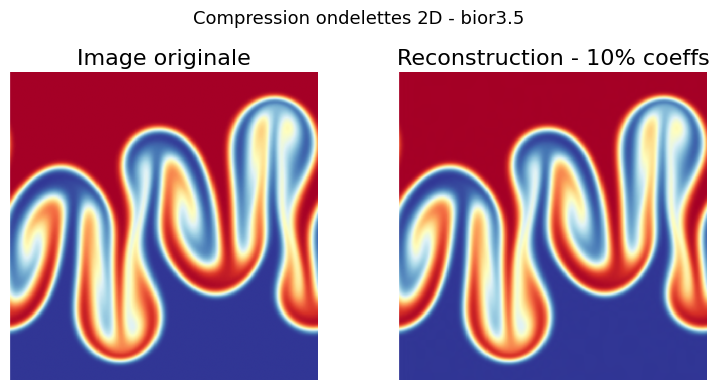

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(img)
ax[0].set_title("Image originale")
ax[0].axis("off")

ax[1].imshow(img_wavelet)
ax[1].set_title(f"Reconstruction - {100*ratio_coeffs:.0f}% coeffs")
ax[1].axis("off")

# ax[2].imshow(mask_wavelet, cmap="gray")
# ax[2].set_title("Coefficients conservés")
# ax[2].axis("off")

fig.suptitle(f"Compression ondelettes 2D - {wavelet_2d}", fontsize=13)
plt.tight_layout()
plt.savefig("2DExemple_Reconstruction.png", dpi=300)
plt.show()



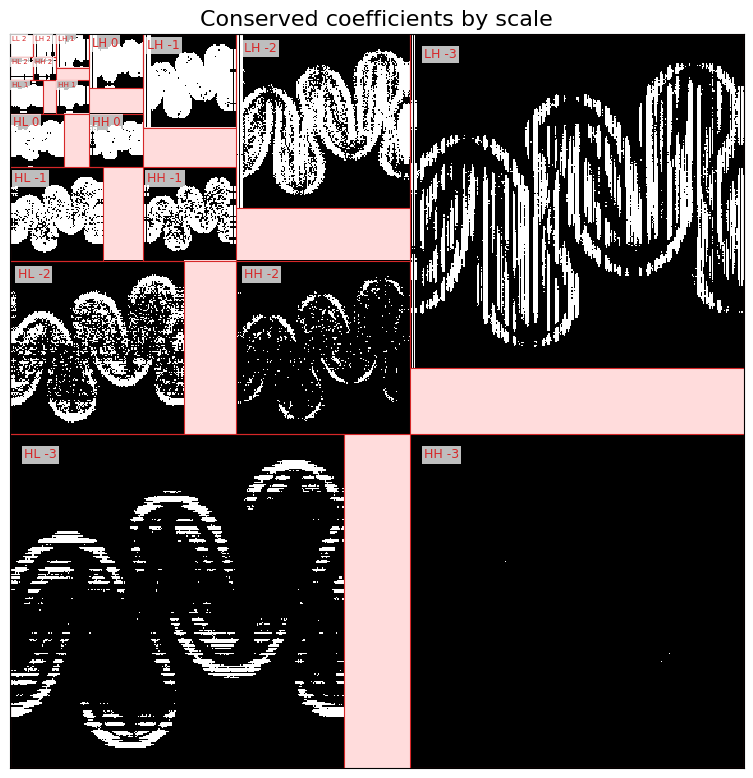

In [ ]:
def plot_wavelet_mask_by_scale(mask, coeffs_slices, cmap="gray", padding_color=(255,220,220)):
    """Affiche chaque sous-bande à sa vraie position dans le plan des coefficients."""
    # n_levels = len(coeffs_slices) - 1
    n_levels = 2
    mask_layout = np.full(mask.shape, np.nan)

    def normalize_block(block):
        block = block.astype(float)
        bmin, bmax = np.min(block), np.max(block)

        if bmax == bmin:
            return np.zeros_like(block) + bmax
        return (block - bmin) / (bmax - bmin)

    def slice_bounds(slc):
        rows, cols = slc
        y0 = rows.start or 0
        y1 = rows.stop
        x0 = cols.start or 0
        x1 = cols.stop
        return x0, x1, y0, y1

    def add_band(ax, slc, label):
        x0, x1, y0, y1 = slice_bounds(slc)
        width = x1 - x0
        height = y1 - y0
        block = normalize_block(mask[slc])
        mask_layout[slc] = block
        label_size = np.clip(min(width, height) / 5, 5, 9)
        label_pad = max(1.0, min(width, height) * 0.04)

        ax.add_patch(
            plt.Rectangle(
                (x0 - 0.5, y0 - 0.5),
                width,
                height,
                fill=False,
                edgecolor="tab:red",
                linewidth=0.8,
            )
        )
        ax.text(
            x0 + label_pad,
            y0 + label_pad,
            label,
            ha="left",
            va="top",
            fontsize=label_size,
            color="tab:red",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5},
        )

    fig, ax = plt.subplots(figsize=(8, 8))

    add_band(ax, coeffs_slices[0], f"LL {n_levels}")

    # PyWavelets stocke les sous-bandes 2D avec les clés ad, da, dd.
    bands = [("LH", "ad"), ("HL", "da"), ("HH", "dd")]
    for row, level_slices in enumerate(coeffs_slices[1:], start=1):
        level = n_levels - row + 1

        for band_name, band_key in bands:
            add_band(ax, level_slices[band_key], f"{band_name} {level}")

    padding_color = np.asarray(padding_color) / 255
    cmap_plot = plt.get_cmap(cmap).copy()

    cmap_plot.set_bad(padding_color)
    ax.imshow(mask_layout, cmap=cmap_plot, interpolation="nearest")

    ax.set_title("Conserved coefficients by scale")
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()
    plt.savefig("../doc/BDRPReportTemplate/figures/ch2/2DExemple_Masque.png", dpi=300, bbox_inches="tight")
    plt.show()
    


plot_wavelet_mask_by_scale(mask_wavelet, coeffs_slices)
